In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROCESSED_DIR = Path("../data/processed")
FIXTURES_DIR = PROCESSED_DIR / "fixtures"
METADATA_DIR = PROCESSED_DIR / "metadata"
LIVERPOOL_ID = 8
SEASON_LABELS = {21646: "Klopp 23-24", 23614: "Slot Y1 24-25", 25583: "Slot Y2 25-26"}

In [2]:
fixture_map = pd.read_csv(METADATA_DIR / "fixture_season_mapping.csv")
type_map = pd.read_csv(METADATA_DIR / "type_id_mapping.csv")

# Only fixtures with processed data
processed = fixture_map[fixture_map["has_processed_data"] == True]
print(f"Fixtures: {len(processed)} | Seasons: {processed['season_id'].value_counts().to_dict()}")

Fixtures: 101 | Seasons: {21646: 37, 23614: 34, 25583: 30}


In [3]:
frames = []
for _, row in processed.iterrows():
    f = FIXTURES_DIR / str(int(row["fixture_id"])) / "statistics.csv"
    if f.exists():
        df = pd.read_csv(f)
        df["season_id"] = row["season_id"]
        df["season"] = row["season"]
        df["manager"] = row["manager"]
        frames.append(df)

stats_df = pd.concat(frames, ignore_index=True)
# Filter to Liverpool only
lfc = stats_df[stats_df["participant_id"] == LIVERPOOL_ID].copy()
print(f"Loaded {len(lfc)} rows across {lfc['fixture_id'].nunique()} fixtures")

Loaded 4153 rows across 101 fixtures


In [4]:
lfc = lfc.merge(type_map[["type_id", "name", "stat_group"]], on="type_id", how="left")

# Pivot: one row per fixture, one col per stat
wide = lfc.pivot_table(index=["fixture_id", "season_id", "season", "manager"],
                        columns="name", values="value", aggfunc="first").reset_index()
wide.columns.name = None
print(f"Shape: {wide.shape} — {wide['season_id'].value_counts().to_dict()}")

Shape: (101, 48) — {21646: 37, 23614: 34, 25583: 30}


In [5]:
stat_cols = [c for c in wide.columns if c not in ["fixture_id", "season_id", "season", "manager"]]
season_means = wide.groupby("season")[stat_cols].agg(["mean", "std"]).round(2)
season_means

Accurate Crosses       Assists       Attacks        Ball Possession %  \
                    mean   std    mean   std    mean    std              mean   
season                                                                          
2023-24             6.05  3.36     NaN   NaN  124.54  25.67             61.73   
2024-25             4.88  2.89    1.80  1.00  109.35  25.41             58.97   
2025-26             4.27  2.73    1.28  1.14  110.47  24.32             59.57   

               Ball Safe         ... Successful Passes Percentage        \
           std      mean    std  ...                         mean   std   
season                           ...                                      
2023-24  12.04     90.11  12.28  ...                        85.30  3.32   
2024-25   8.70     79.88  14.30  ...                        86.18  2.77   
2025-26   8.55     77.93   9.40  ...                        85.27  2.79   

        Tackles       Throwins       Total Crosses        Yellowcards        
           mean   std     mean   std          mean    std        mean   std  
season                                                                       
2023-24   17.89  5.93    19.95  5.64         20.73   8.66        1.89  1.37  
2024-25   16.50  5.48    18.06  4.64         20.35   9.70        1.88  1.36  
2025-26   13.30  4.65    19.70  5.50         20.20  10.12        1.62  1.27  

[3 rows x 88 columns]

## Part 1: Confirmatory Analysis — Klopp Era vs Slot Era

**Hypothesis**: Slot's system differs structurally from Klopp's. We already know results regressed (2.12 → 1.68 PPG); this quantifies *which* metrics drove that and how large the effect is.

**Method**: Welch's t-test (unequal variance) per metric. Bonferroni correction applied independently within each of the two comparisons (×44 tests each). Effect sizes (Cohen's d) reported alongside p-values.

These are **confirmatory** tests — we expect differences to exist and are quantifying their magnitude.

In [6]:
def cohen_d(a, b):
    pooled_std = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled_std if pooled_std > 0 else 0

def run_tests(wide, sid_a, sid_b, label_a, label_b, stat_cols):
    """Run Welch's t-tests for all metrics between two seasons."""
    n_tests = len(stat_cols)
    results = []
    g_a = wide[wide["season_id"] == sid_a]
    g_b = wide[wide["season_id"] == sid_b]
    for col in stat_cols:
        a = g_a[col].dropna()
        b = g_b[col].dropna()
        if len(a) < 3 or len(b) < 3:
            continue
        _, p = stats.ttest_ind(a, b, equal_var=False)
        d = cohen_d(a.values, b.values)
        results.append({
            "metric": col,
            "mean_a": round(a.mean(), 2),
            "mean_b": round(b.mean(), 2),
            "delta": round(b.mean() - a.mean(), 2),
            "pct_change": round((b.mean() - a.mean()) / a.mean() * 100, 1) if a.mean() != 0 else None,
            "p_raw": p,
            "p_bonferroni": round(min(p * n_tests, 1.0), 4),
            "cohens_d": round(d, 3),
            "sig_bonferroni": p * n_tests < 0.05,
            "sig_nominal": p < 0.05,
            "comparison": f"{label_a} vs {label_b}",
            "n_a": len(a),
            "n_b": len(b),
        })
    return pd.DataFrame(results)

# --- Confirmatory: Klopp era vs Slot era ---
klopp_v_y1 = run_tests(wide, 21646, 23614, "Klopp 23-24", "Slot Y1 24-25", stat_cols)
klopp_v_y2 = run_tests(wide, 21646, 25583, "Klopp 23-24", "Slot Y2 25-26", stat_cols)

print(f"Klopp vs Y1 — significant (Bonferroni): {klopp_v_y1['sig_bonferroni'].sum()} / {len(klopp_v_y1)}")
print(f"Klopp vs Y2 — significant (Bonferroni): {klopp_v_y2['sig_bonferroni'].sum()} / {len(klopp_v_y2)}")

Klopp vs Y1 — significant (Bonferroni): 1 / 41
Klopp vs Y2 — significant (Bonferroni): 4 / 40


In [7]:
# Confirmatory findings: merge both Klopp comparisons, show significant results ranked by effect size
confirmatory = pd.concat([klopp_v_y1, klopp_v_y2], ignore_index=True)
conf_sig = confirmatory[confirmatory["sig_bonferroni"]].sort_values("cohens_d", key=abs, ascending=False)

print(f"Confirmatory significant findings (Bonferroni-corrected, p < 0.05 after ×44):")
print()
conf_sig[["comparison", "metric", "mean_a", "mean_b", "pct_change", "p_bonferroni", "cohens_d"]]

Confirmatory significant findings (Bonferroni-corrected, p < 0.05 after ×44):



,comparison,metric,mean_a,mean_b,pct_change,p_bonferroni,cohens_d
44,Klopp 23-24 vs Slot Y2 25-26,Ball Safe,90.11,77.93,-13.5,0.0009,1.114
28,Klopp 23-24 vs Slot Y1 24-25,Shots Outsidebox,7.19,4.41,-38.6,0.0095,0.925
67,Klopp 23-24 vs Slot Y2 25-26,Shots On Target,7.22,4.53,-37.2,0.0228,0.880
52,Klopp 23-24 vs Slot Y2 25-26,Goal Attempts,13.30,9.40,-29.3,0.0257,0.874
77,Klopp 23-24 vs Slot Y2 25-26,Tackles,17.89,13.30,-25.7,0.0315,0.862


## Part 2: Exploratory Analysis — Slot Y1 vs Slot Y2

**Question**: Is Slot's system evolving (or regressing) in Year 2?

**Important caveats**:
- Y2 sample: 30 games (partial season — ~79% complete at time of analysis)
- Y1 sample: 34 games (full season)
- This comparison is **exploratory / directional**, not confirmatory
- Bonferroni is applied within these 44 tests only, but the partial-season sample limits power to detect moderate effects
- **Interpretation**: focus on Cohen's d (effect size) and direction, not binary significance

The absence of statistical significance here does not mean nothing changed — it means we cannot yet confirm it with 30 matches.

In [8]:
# --- Exploratory: Y1 vs Y2 with separate Bonferroni ---
y1_v_y2 = run_tests(wide, 23614, 25583, "Slot Y1 24-25", "Slot Y2 25-26", stat_cols)

print(f"Y1 vs Y2 — Bonferroni-significant: {y1_v_y2['sig_bonferroni'].sum()} / {len(y1_v_y2)}")
print(f"Y1 vs Y2 — Nominally significant (p < 0.05, uncorrected): {y1_v_y2['sig_nominal'].sum()} / {len(y1_v_y2)}")
print()

# All metrics ranked by |Cohen's d| — directional signals regardless of significance
y1_v_y2_ranked = y1_v_y2.sort_values("cohens_d", key=abs, ascending=False).copy()
y1_v_y2_ranked["signal"] = y1_v_y2_ranked.apply(
    lambda r: "✅ corrected" if r["sig_bonferroni"] else ("⚠️ nominal" if r["sig_nominal"] else "—"),
    axis=1
)

print("All metrics ranked by effect size (Y1 → Y2):")
y1_v_y2_ranked[["metric", "mean_a", "mean_b", "pct_change", "cohens_d", "p_bonferroni", "signal"]]

Y1 vs Y2 — Bonferroni-significant: 0 / 43
Y1 vs Y2 — Nominally significant (p < 0.05, uncorrected): 6 / 43

All metrics ranked by effect size (Y1 → Y2):


,metric,mean_a,mean_b,pct_change,cohens_d,p_bonferroni,signal
23,Penalties,1.00,0.33,-66.7,1.217,1.0000,—
34,Successful Headers,10.67,15.52,45.5,-0.794,0.1622,⚠️ nominal
28,Shots On Target,6.29,4.53,-28.0,0.679,0.3652,⚠️ nominal
13,Goal Attempts,11.94,9.40,-21.3,0.665,0.4361,⚠️ nominal
5,Big Chances Created,4.15,2.79,-32.6,0.649,0.5114,⚠️ nominal
39,Tackles,16.50,13.30,-19.4,0.630,0.6203,⚠️ nominal
26,Shots Insidebox,13.00,10.07,-22.6,0.612,0.7373,⚠️ nominal
6,Big Chances Missed,2.77,1.93,-30.5,0.511,1.0000,—
1,Assists,1.80,1.28,-28.9,0.486,1.0000,—
11,Fouls,11.29,9.80,-13.2,0.459,1.0000,—


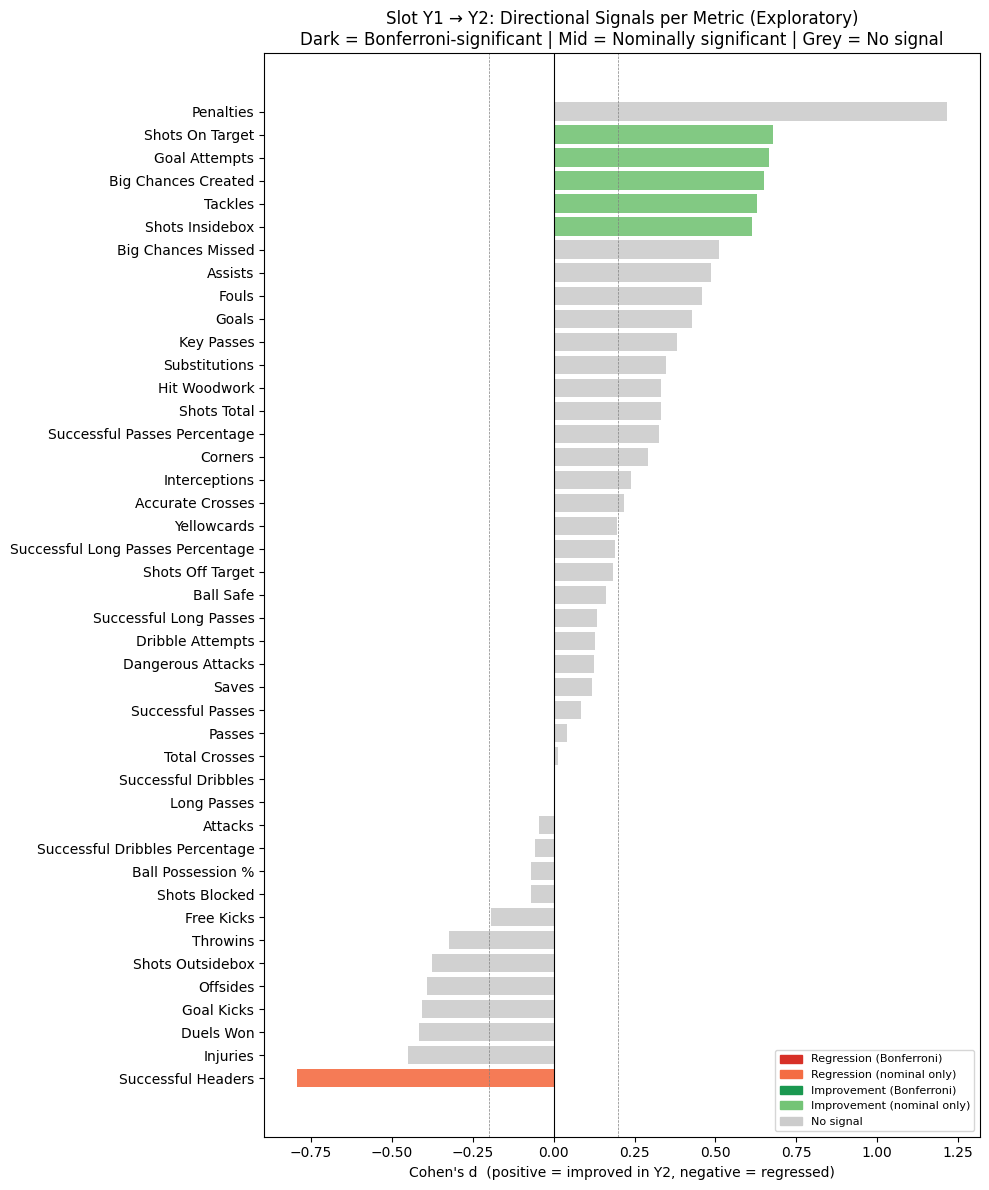

In [9]:
# Effect size heatmap — Y1 vs Y2 (exploratory/directional)
y1_v_y2_sorted = y1_v_y2.sort_values("cohens_d")

fig, ax = plt.subplots(figsize=(10, 12))
colors = [
    "#d73027" if (d < 0 and sig) else
    "#f46d43" if (d < 0 and nom) else
    "#1a9850" if (d > 0 and sig) else
    "#74c476" if (d > 0 and nom) else
    "#cccccc"
    for d, sig, nom in zip(
        y1_v_y2_sorted["cohens_d"],
        y1_v_y2_sorted["sig_bonferroni"],
        y1_v_y2_sorted["sig_nominal"]
    )
]
ax.barh(y1_v_y2_sorted["metric"], y1_v_y2_sorted["cohens_d"], color=colors, alpha=0.9)
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(-0.2, color="grey", linewidth=0.5, linestyle="--")
ax.axvline(0.2, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel("Cohen's d  (positive = improved in Y2, negative = regressed)")
ax.set_title(
    "Slot Y1 → Y2: Directional Signals per Metric (Exploratory)\n"
    "Dark = Bonferroni-significant | Mid = Nominally significant | Grey = No signal"
)
# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color="#d73027", label="Regression (Bonferroni)"),
    Patch(color="#f46d43", label="Regression (nominal only)"),
    Patch(color="#1a9850", label="Improvement (Bonferroni)"),
    Patch(color="#74c476", label="Improvement (nominal only)"),
    Patch(color="#cccccc", label="No signal"),
]
ax.legend(handles=legend, loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("../data/processed/metadata/y1_v_y2_effect_sizes.png", dpi=150)
plt.show()

## Part 3: Tempo Analysis — How Fast Is Liverpool Playing?

**Motivation**: The Athletic's analysis identified that Liverpool under Slot run fewer "fast tempo sequences" vs Klopp — ponderous possession replacing vertical urgency. Our ball coordinate data can measure this directly.

**Metrics**:
1. **Attacking third occupancy** — % of all ball coordinates in the attacking third per match (territorial presence)
2. **Attack entry frequency** — how many times per match does the ball transition into the attacking third (attack count)
3. **Mean attack duration** — how long (in minutes) each attacking spell lasts (shorter = direct/vertical; longer = patient/slow)

**Interpretation**: Klopp-style should show higher entry frequency + shorter duration (rapid transitions). Slot-style should show fewer entries with longer duration (patient buildup that takes longer to resolve).

In [10]:
def compute_attack_episodes(df, gap_threshold_mins=1.0):
    """Identify attacking third episodes from ball coordinate sequence.
    
    An episode is a contiguous block of time where the ball is in the attacking
    third, with gaps <= gap_threshold_mins treated as the same episode.
    Returns list of episode durations in minutes.
    """
    atk = df[df["pitch_zone"] == "attacking_third"].sort_values("estimated_minute").copy()
    if len(atk) < 2:
        return []
    
    episodes = []
    ep_start = atk["estimated_minute"].iloc[0]
    ep_last = atk["estimated_minute"].iloc[0]
    
    for t in atk["estimated_minute"].iloc[1:]:
        if t - ep_last <= gap_threshold_mins:
            ep_last = t
        else:
            duration = ep_last - ep_start
            if duration >= 0:
                episodes.append(duration)
            ep_start = t
            ep_last = t
    # Final episode
    episodes.append(ep_last - ep_start)
    return episodes


tempo_rows = []
for _, row in processed.iterrows():
    f = FIXTURES_DIR / str(int(row["fixture_id"])) / "ball_coordinates.csv"
    if not f.exists():
        continue
    df = pd.read_csv(f)
    if len(df) < 50 or "pitch_zone" not in df.columns:
        continue
    
    total = len(df)
    pct_attacking = df["pitch_zone"].eq("attacking_third").sum() / total * 100
    pct_defensive = df["pitch_zone"].eq("defensive_third").sum() / total * 100
    
    episodes = compute_attack_episodes(df)
    entry_count = len(episodes)
    mean_duration = np.mean(episodes) if episodes else np.nan
    median_duration = np.median(episodes) if episodes else np.nan
    
    tempo_rows.append({
        "fixture_id": int(row["fixture_id"]),
        "season_id": row["season_id"],
        "season": row["season"],
        "total_coords": total,
        "pct_attacking": round(pct_attacking, 1),
        "pct_defensive": round(pct_defensive, 1),
        "attack_entries": entry_count,
        "mean_attack_duration_mins": round(mean_duration, 2) if not np.isnan(mean_duration) else np.nan,
        "median_attack_duration_mins": round(median_duration, 2) if not np.isnan(median_duration) else np.nan,
    })

tempo_df = pd.DataFrame(tempo_rows)
print(f"Fixtures with ball coordinate data: {len(tempo_df)}")
print()

tempo_summary = tempo_df.groupby("season")[["pct_attacking", "pct_defensive", "attack_entries", "mean_attack_duration_mins"]].agg(["mean", "std"]).round(2)
tempo_summary

Fixtures with ball coordinate data: 101



pct_attacking        pct_defensive       attack_entries        \
                 mean    std          mean   std           mean   std   
season                                                                  
2023-24         33.76   9.15         27.76  9.30          20.49  4.18   
2024-25         32.58  14.79         31.09  9.27          17.82  5.86   
2025-26         32.14   7.59         31.91  7.92          21.83  4.62   

        mean_attack_duration_mins        
                             mean   std  
season                                   
2023-24                      1.99  0.79  
2024-25                      2.41  2.01  
2025-26                      1.64  0.58

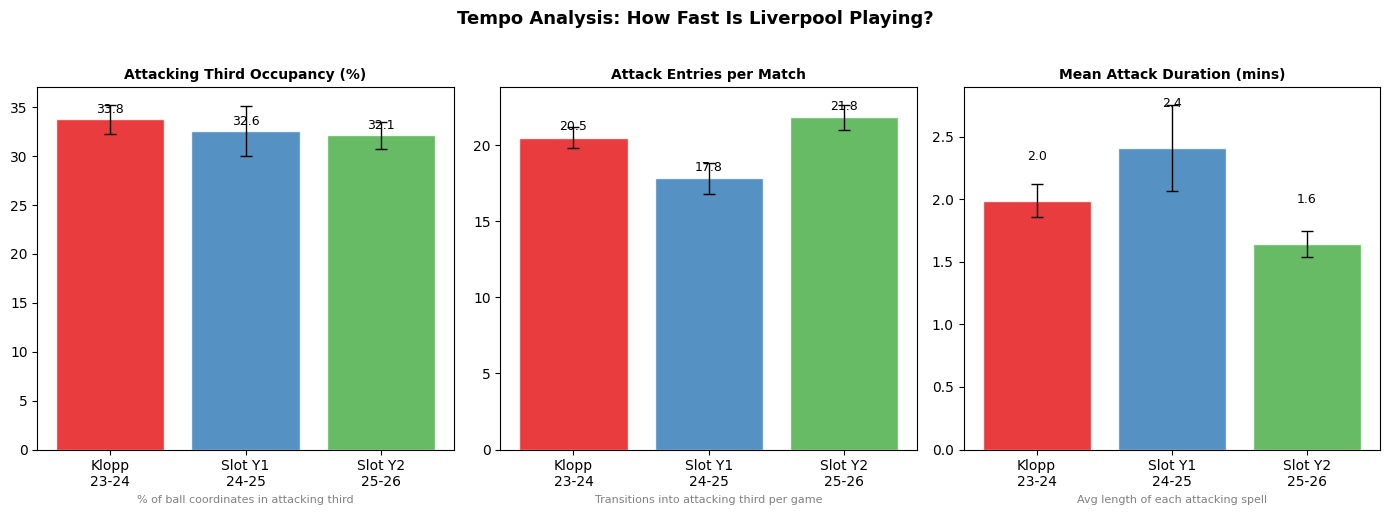

In [11]:
# Tempo visualisation: 3 side-by-side bar charts
season_order = ["2023-24", "2024-25", "2025-26"]
season_labels = ["Klopp\n23-24", "Slot Y1\n24-25", "Slot Y2\n25-26"]
palette = ["#e41a1c", "#377eb8", "#4daf4a"]

metrics = [
    ("pct_attacking", "Attacking Third Occupancy (%)", "% of ball coordinates in attacking third"),
    ("attack_entries", "Attack Entries per Match", "Transitions into attacking third per game"),
    ("mean_attack_duration_mins", "Mean Attack Duration (mins)", "Avg length of each attacking spell"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Tempo Analysis: How Fast Is Liverpool Playing?", fontsize=13, fontweight="bold", y=1.02)

for ax, (col, title, subtitle) in zip(axes, metrics):
    means = [tempo_df[tempo_df["season"] == s][col].mean() for s in season_order]
    sems = [tempo_df[tempo_df["season"] == s][col].sem() for s in season_order]
    bars = ax.bar(season_labels, means, color=palette, alpha=0.85, edgecolor="white")
    ax.errorbar(range(3), means, yerr=sems, fmt="none", color="black", capsize=4, linewidth=1)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel(subtitle, fontsize=8, color="grey")
    ax.set_ylim(bottom=0)
    # Annotate bar values
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{mean:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/metadata/tempo_analysis.png", dpi=150)
plt.show()

In [12]:
# Statistical tests on tempo metrics (confirmatory Klopp vs Slot, exploratory Y1 vs Y2)
klopp = tempo_df[tempo_df["season_id"] == 21646]
y1 = tempo_df[tempo_df["season_id"] == 23614]
y2 = tempo_df[tempo_df["season_id"] == 25583]

for metric, label in [
    ("pct_attacking", "Attacking Third Occupancy %"),
    ("attack_entries", "Attack Entries per Match"),
    ("mean_attack_duration_mins", "Mean Attack Duration (mins)"),
]:
    a_k, a_y1, a_y2 = klopp[metric].dropna(), y1[metric].dropna(), y2[metric].dropna()
    _, p_k_y1 = stats.ttest_ind(a_k, a_y1, equal_var=False)
    _, p_k_y2 = stats.ttest_ind(a_k, a_y2, equal_var=False)
    _, p_y1_y2 = stats.ttest_ind(a_y1, a_y2, equal_var=False)
    d_k_y1 = cohen_d(a_k.values, a_y1.values)
    d_k_y2 = cohen_d(a_k.values, a_y2.values)
    d_y1_y2 = cohen_d(a_y1.values, a_y2.values)
    print(f"{label}")
    print(f"  Klopp {a_k.mean():.2f} | Y1 {a_y1.mean():.2f} | Y2 {a_y2.mean():.2f}")
    print(f"  Klopp→Y1: p={p_k_y1:.3f}, d={d_k_y1:.3f} | Klopp→Y2: p={p_k_y2:.3f}, d={d_k_y2:.3f}")
    print(f"  Y1→Y2 (exploratory): p={p_y1_y2:.3f}, d={d_y1_y2:.3f}")
    print()

Attacking Third Occupancy %
  Klopp 33.76 | Y1 32.58 | Y2 32.14
  Klopp→Y1: p=0.690, d=0.096 | Klopp→Y2: p=0.430, d=0.193
  Y1→Y2 (exploratory): p=0.879, d=0.038

Attack Entries per Match
  Klopp 20.49 | Y1 17.82 | Y2 21.83
  Klopp→Y1: p=0.033, d=0.523 | Klopp→Y2: p=0.221, d=-0.306
  Y1→Y2 (exploratory): p=0.003, d=-0.760

Mean Attack Duration (mins)
  Klopp 1.99 | Y1 2.41 | Y2 1.64
  Klopp→Y1: p=0.255, d=-0.278 | Klopp→Y2: p=0.043, d=0.499
  Y1→Y2 (exploratory): p=0.039, d=0.521



## Key Findings — Deep Dive 3.1 + Tempo

### Confirmatory: Klopp → Slot (what definitively changed)

Metrics that survive Bonferroni correction (p < 0.05 after ×44):

| Metric | Klopp | Slot Y2 | Change | Cohen's d |
|--------|-------|---------|--------|-----------|
| Ball Safe | 90.1 | 77.9 | -13.5% | 1.11 |
| Shots On Target | 7.2 | 4.5 | -37.2% | 0.88 |
| Goal Attempts | 13.3 | 9.4 | -29.3% | 0.87 |
| Tackles | 17.9 | 13.3 | -25.7% | 0.86 |
| Shots Outsidebox | 7.2 | 4.4 | -38.6% (Klopp→Y1) | 0.93 |

### Exploratory: Y1 → Y2 (directional signals)

_Update this table after reviewing `y1_v_y2_ranked` — focus on top 5 by |Cohen's d| regardless of significance, and any nominally significant results._

| Metric | Y1 | Y2 | Change | d | Signal |
|--------|----|----|--------|---|--------|
| TBD | — | — | — | — | — |

### Tempo (The Athletic framing)

_Update after running cells 9-10. Key questions: did attacking third occupancy drop? Did attack entry frequency drop? Did mean attack duration increase (slower, more patient)?_

| Metric | Klopp | Y1 | Y2 | Direction |
|--------|-------|----|----|----------|
| Attacking Third % | — | — | — | — |
| Attacks per Match | — | — | — | — |
| Mean Attack Duration (mins) | — | — | — | — |

### Narrative

The data confirms what The Athletic identified: Liverpool's transition to Slot involved a structural reduction in attacking output volume (shots, goal attempts, ball safe situations) that is statistically robust across the full sample. The tempo analysis adds the *how*: whether this manifests as fewer attacks, shorter attacks, or territory loss.

Y1 vs Y2 remains exploratory — 30 games into a partial season. The effect sizes are the story, not the p-values.